This is about image style transfer, what exactly in the image data represents the style in the image. We will investigate in this path. We have a mfhusain potriat and his painting, lets style transfer his potrait to his painting.

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.nn import functional as F

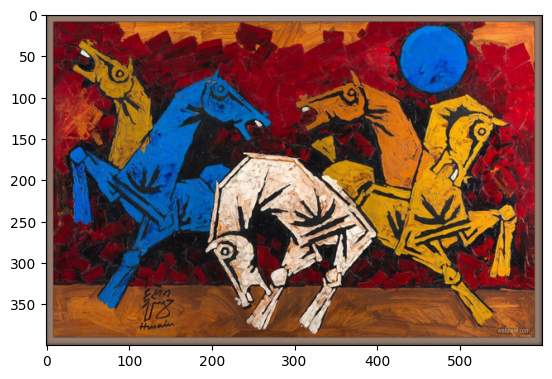

In [4]:
from PIL import Image
mfpnt=Image.open('mfhusain.jpg').resize((600,400))
pnt= np.array(mfpnt)
plt.imshow(pnt)

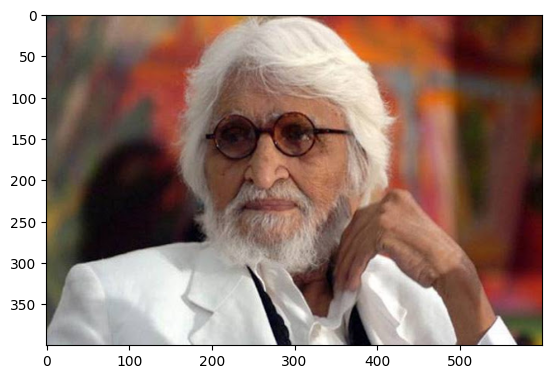

In [5]:
mfptrt= Image.open('mfhussain-portrait.jpg').resize((600,400))
ptrt= np.array(mfptrt)
plt.imshow(ptrt)

What exactly in the image does the style represent,style is something which is consistent across the image, example will be strokes are a certain way, or certain colors are preferred more to others. This can be found my neural net as statistics of the image, so if i can get the normal image to follow the statistics of the style image, then i have transferred the style. We can just use loss function to achieve this.style forms the basic part of the image, so we may need first few layers outputs to be similar to normal image. this is the idea.

In [6]:
feat={}
def get_features(name):
    def hook(model,input,output):
        feat[name]= output.detach()
    return hook

In [7]:
model = torch.hub.load('pytorch/vision:v0.10.0', 'resnet18', pretrained=True)

for name,m in model.named_children():
    m.register_forward_hook(get_features(name))

from torchvision import transforms
preprocess = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
input_tensor = preprocess(mfpnt)
input_batch = input_tensor.unsqueeze(0) # create a mini-batch as expected by the model

with torch.no_grad():
    output = model(input_batch)

Downloading: "https://github.com/pytorch/vision/zipball/v0.10.0" to /root/.cache/torch/hub/v0.10.0.zip
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 360MB/s]


In [8]:
feat.keys()# all the intermediate layers outputs are stored here

dict_keys(['conv1', 'bn1', 'relu', 'maxpool', 'layer1', 'layer2', 'layer3', 'layer4', 'avgpool', 'fc'])

In [9]:
def get_features(name):
    def hook(model,input,output):
        feat_next[name]= output
    return hook

In [10]:
def ten2img(t):
    #reversing all the transforms to plot the image output
    t= t*(torch.tensor([[[0.229]],[[.224]],[[.225]]])) + torch.tensor([[[0.485]], [[0.456]], [[0.406]]])
    t*= 255
    return t.clip(0,255).long()

In [11]:
criterion=nn.MSELoss()

In [12]:
def fcorrelations(x):

    x=x.reshape(64,-1)
    y= x+ 1e-6
    X1= torch.linalg.norm(y,dim=-1,).unsqueeze(-1)
    val= (x@x.T)/X1**1
    #print(val.norm(),X1.data)
    return val

In [13]:
feat= {i:j.to('cuda') for i,j in feat.items()}

Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


Iteration: 0,Loss : 102.631,Loss2: 3.743


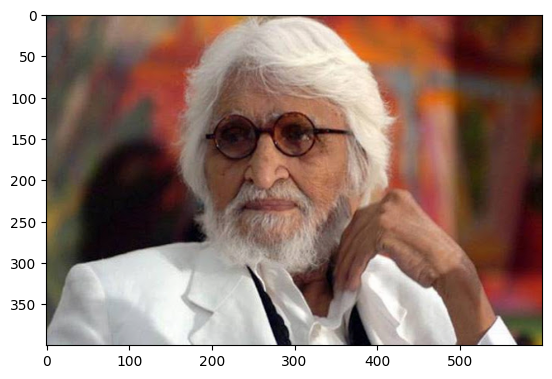

Iteration: 100,Loss : 56.420,Loss2: 2.144
Iteration: 200,Loss : 41.988,Loss2: 2.002
Iteration: 300,Loss : 34.067,Loss2: 1.935
Iteration: 400,Loss : 28.767,Loss2: 1.900
Iteration: 500,Loss : 24.820,Loss2: 1.879
Iteration: 600,Loss : 21.719,Loss2: 1.860
Iteration: 700,Loss : 19.178,Loss2: 1.847
Iteration: 800,Loss : 17.057,Loss2: 1.838
Iteration: 900,Loss : 15.266,Loss2: 1.829
Iteration: 1000,Loss : 13.744,Loss2: 1.821
Iteration: 1100,Loss : 12.425,Loss2: 1.815
Iteration: 1200,Loss : 11.275,Loss2: 1.810
Iteration: 1300,Loss : 10.265,Loss2: 1.804
Iteration: 1400,Loss : 9.381,Loss2: 1.799
Iteration: 1500,Loss : 8.601,Loss2: 1.795
Iteration: 1600,Loss : 7.913,Loss2: 1.792
Iteration: 1700,Loss : 7.296,Loss2: 1.788
Iteration: 1800,Loss : 6.744,Loss2: 1.785
Iteration: 1900,Loss : 6.247,Loss2: 1.782
Iteration: 2000,Loss : 5.801,Loss2: 1.778


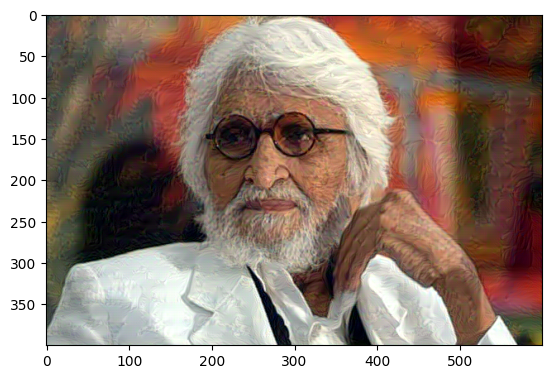

Iteration: 2100,Loss : 5.399,Loss2: 1.775
Iteration: 2200,Loss : 5.035,Loss2: 1.772
Iteration: 2300,Loss : 4.706,Loss2: 1.769
Iteration: 2400,Loss : 4.408,Loss2: 1.766
Iteration: 2500,Loss : 4.135,Loss2: 1.763
Iteration: 2600,Loss : 3.886,Loss2: 1.760
Iteration: 2700,Loss : 3.657,Loss2: 1.758
Iteration: 2800,Loss : 3.448,Loss2: 1.755
Iteration: 2900,Loss : 3.256,Loss2: 1.753
Iteration: 3000,Loss : 3.079,Loss2: 1.750
Iteration: 3100,Loss : 2.915,Loss2: 1.747
Iteration: 3200,Loss : 2.763,Loss2: 1.745
Iteration: 3300,Loss : 2.622,Loss2: 1.743
Iteration: 3400,Loss : 2.489,Loss2: 1.741
Iteration: 3500,Loss : 2.367,Loss2: 1.739
Iteration: 3600,Loss : 2.252,Loss2: 1.738
Iteration: 3700,Loss : 2.145,Loss2: 1.736
Iteration: 3800,Loss : 2.045,Loss2: 1.734
Iteration: 3900,Loss : 1.952,Loss2: 1.733
Iteration: 4000,Loss : 1.864,Loss2: 1.731


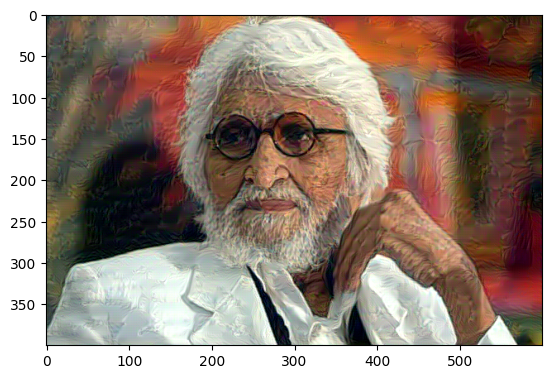

Iteration: 4100,Loss : 1.781,Loss2: 1.730
Iteration: 4200,Loss : 1.703,Loss2: 1.728
Iteration: 4300,Loss : 1.630,Loss2: 1.727
Iteration: 4400,Loss : 1.560,Loss2: 1.725
Iteration: 4500,Loss : 1.494,Loss2: 1.724
Iteration: 4600,Loss : 1.431,Loss2: 1.722
Iteration: 4700,Loss : 1.371,Loss2: 1.721
Iteration: 4800,Loss : 1.314,Loss2: 1.720
Iteration: 4900,Loss : 1.260,Loss2: 1.719
Iteration: 5000,Loss : 1.208,Loss2: 1.718
Iteration: 5100,Loss : 1.159,Loss2: 1.717
Iteration: 5200,Loss : 1.112,Loss2: 1.715
Iteration: 5300,Loss : 1.066,Loss2: 1.714
Iteration: 5400,Loss : 1.023,Loss2: 1.713
Iteration: 5500,Loss : 0.981,Loss2: 1.712
Iteration: 5600,Loss : 0.941,Loss2: 1.711
Iteration: 5700,Loss : 0.902,Loss2: 1.710
Iteration: 5800,Loss : 0.865,Loss2: 1.709
Iteration: 5900,Loss : 0.830,Loss2: 1.708
Iteration: 6000,Loss : 0.796,Loss2: 1.708


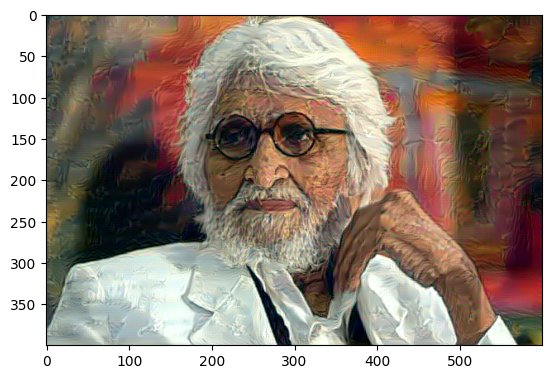

Iteration: 6100,Loss : 0.763,Loss2: 1.707
Iteration: 6200,Loss : 0.731,Loss2: 1.706
Iteration: 6300,Loss : 0.701,Loss2: 1.705
Iteration: 6400,Loss : 0.673,Loss2: 1.704
Iteration: 6500,Loss : 0.645,Loss2: 1.704
Iteration: 6600,Loss : 0.618,Loss2: 1.703
Iteration: 6700,Loss : 0.592,Loss2: 1.702
Iteration: 6800,Loss : 0.568,Loss2: 1.701
Iteration: 6900,Loss : 0.544,Loss2: 1.701
Iteration: 7000,Loss : 0.521,Loss2: 1.700
Iteration: 7100,Loss : 0.499,Loss2: 1.700
Iteration: 7200,Loss : 0.478,Loss2: 1.699
Iteration: 7300,Loss : 0.457,Loss2: 1.698
Iteration: 7400,Loss : 0.437,Loss2: 1.698
Iteration: 7500,Loss : 0.418,Loss2: 1.697
Iteration: 7600,Loss : 0.400,Loss2: 1.697
Iteration: 7700,Loss : 0.383,Loss2: 1.696
Iteration: 7800,Loss : 0.366,Loss2: 1.695
Iteration: 7900,Loss : 0.349,Loss2: 1.695
Iteration: 8000,Loss : 0.334,Loss2: 1.694


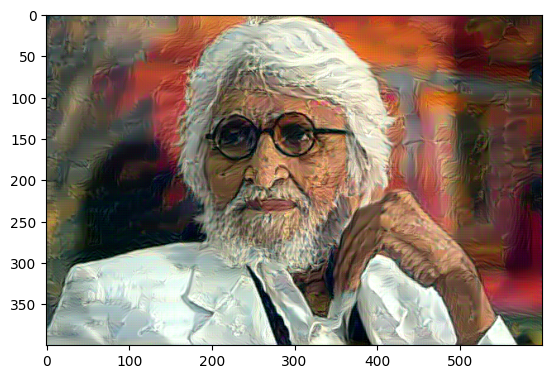

Iteration: 8100,Loss : 0.319,Loss2: 1.694
Iteration: 8200,Loss : 0.304,Loss2: 1.693
Iteration: 8300,Loss : 0.290,Loss2: 1.693
Iteration: 8400,Loss : 0.277,Loss2: 1.692
Iteration: 8500,Loss : 0.264,Loss2: 1.692
Iteration: 8600,Loss : 0.252,Loss2: 1.691
Iteration: 8700,Loss : 0.240,Loss2: 1.691
Iteration: 8800,Loss : 0.229,Loss2: 1.690
Iteration: 8900,Loss : 0.218,Loss2: 1.690
Iteration: 9000,Loss : 0.208,Loss2: 1.689
Iteration: 9100,Loss : 0.198,Loss2: 1.689
Iteration: 9200,Loss : 0.188,Loss2: 1.688
Iteration: 9300,Loss : 0.179,Loss2: 1.688
Iteration: 9400,Loss : 0.171,Loss2: 1.688
Iteration: 9500,Loss : 0.163,Loss2: 1.687
Iteration: 9600,Loss : 0.155,Loss2: 1.687
Iteration: 9700,Loss : 0.147,Loss2: 1.686
Iteration: 9800,Loss : 0.140,Loss2: 1.686
Iteration: 9900,Loss : 0.133,Loss2: 1.686
Iteration: 10000,Loss : 0.127,Loss2: 1.685


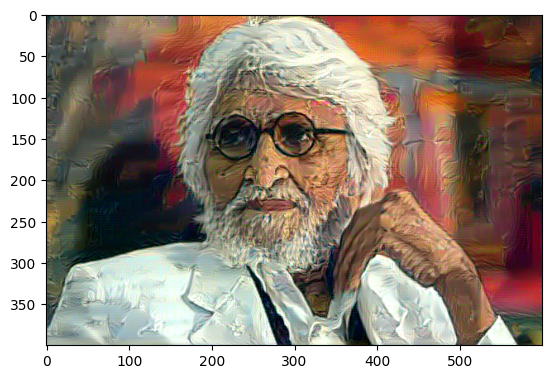

In [28]:
model = torch.hub.load('pytorch/vision:v0.10.0', 'resnet18', pretrained=True)
for name,m in model.named_children():
    if name in [ 'maxpool','conv1','bn1','relu','avgpool','layer1','layer2']:
        m.register_forward_hook(get_features(name))

for m in model.parameters(): m.requires_grad=False

preprocess = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
input_tensor = preprocess(mfptrt)
input_batch = input_tensor.unsqueeze(0) # create a mini-batch as expected by the model
input_batch_target= input_batch.detach().clone()
feat_next={}
with torch.no_grad():model(input_batch)

model.to('cuda')
input_avg_target= feat_next['avgpool'].detach().cuda()

#klloss= nn.KLDivLoss(reduction='batchmean')
input_batch=input_batch.to('cuda')
input_batch.requires_grad=True
optimizer= torch.optim.Adam([input_batch],lr=3e-4)

model.eval()
for i in range (10100):
    feat_next={}
    output = model(input_batch)
    #loss1= [klloss((F.max_pool2d(feat_next[i],kernel_size=(1,300))+1e-6).log(),(F.max_pool2d(feat[i],kernel_size=(1,300))+1e-6)).mean()  for i in [ 'bn1','relu']]#conv1 removed giving nans, deal with 0s in kldiv loss
    loss1= [criterion(fcorrelations(feat_next[i]),fcorrelations(feat[i])) for i in ['layer1']]
    loss2= 2*sum([criterion(output,input_avg_target) for i in ['']])
    #print(f'Loss: {loss1}')
    loss1= torch.clip(sum(loss1)*1,min=0)
    if i%100==0:
        print(f'Iteration: {i},Loss : {loss1:.3f},Loss2: {loss2:.3f}')
    loss= loss1 + loss2
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    if i%2000==0:
        plt.imshow(ten2img(input_batch[0].detach().clone().cpu()).permute(1,2,0))
        plt.pause(.5)

In [16]:
#experiment results simplyfiyng by checking each layer, maxpool, was very similar already, so moving on to next 'layer1', this is the one we need, it has adanced features that we need.

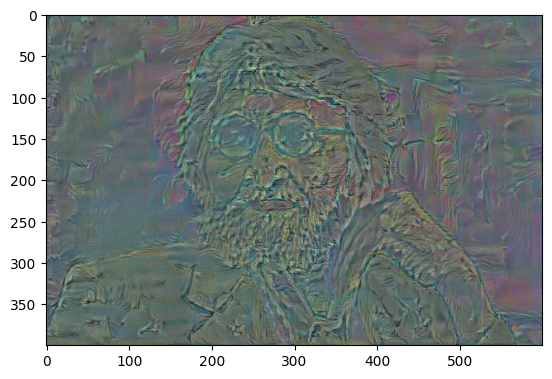

In [31]:
#subtarct original ptrt from  this,then clearly differences can be seen.
plt.imshow(ten2img(input_batch[0].detach().clone().cpu()).permute(1,2,0) - torch.tensor(ptrt)+100)
#we can see that it is trying to superimpose the image, it is doing it on whole image,

The painting strokes is what the model is trying to mimic, some high level features like eyes are also seen, these should be avoided, we may need to move down to lower layers, then those features/style can be achieved.

In [18]:
feat['layer1'].shape,# there are 64 features we need, we need to jumble them and then optimize to get the style right, without mimicking the exact image.

(torch.Size([1, 64, 100, 150]),)

In [ ]:
# why not check if values follow the same distribution or not, we can use kl divergence loss to check this.
#2 problems here, it expects everything to be positive and greater than 0, because it uses log on outputs.

The following is done,firstly we tried to target the distribution of style image,it didnt work as expected(it is just copying the style image as it is), so we max pooled the inputs to the loss to get it to jumble things instead of mere copying and this was working better , but as proposed in Gatys et al, using gram matrices did give best results, so it is shown using fcorrelations method.